In [ ]:
# Download the sentence transformers package, which we will be using to encode book descriptions/synopses as vectors
# Only need to do once. Uncomment to download yourself 
# %pip install -U sentence_transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
hugo_finalists = pd.read_csv('../data/hugo_nominees.csv')

hugo_finalists.tail()

,title,author,year
360,A Drop of Corruption,Robert Jackson Bennett,2026
361,The Everlasting,Alix E. Harrow,2026
362,The Incandescent,Emily Tesh,2026
363,The Raven Scholar,Antonia Hodgson,2026
364,Shroud,Adrian Tchaikovsky,2026


In [4]:
# lets use the hardcover book details, since those I assume has more complete data

hardcover = pd.read_csv('../data/hardcover_bookdetails.csv', sep='\t')

In [48]:
hardcover = hardcover.dropna()
hardcover

,batch_num,isbn,title,description,tags
0,0,0553408534,Conquerors' Pride,"Timothy Zahn, Hugo Award-winning author of The...","[{'Fiction': 1}, {'Science Fiction': 1}, {'Fan..."
1,0,0671655981,Spinneret,"Set in the crowded galaxy of the future, Earth...","[{'Fiction': 1}, {'Science fiction': 1}]"
2,0,0553564927,The Last Command,The conclusion to the epic adventure begun in ...,"[{'Science Fiction': 3}, {'Fantasy': 2}, {'Fic..."
3,0,0345350375,Tarzan and the Madman,Synopsis - A beautiful white girl on safari is...,"[{'Fantasy': 19637}, {'Fiction': 18540}, {'Adv..."
4,0,055310652X,The Rise of Endymion,The time of reckoning has arrived. As a final ...,"[{'Fantasy': 2}, {'Science Fiction': 2}, {'Fic..."
...,...,...,...,...,...
49050,2699,9798312044966,Mage Tank: A LitRPG Adventure,After being killed by a high-velocity tree-hug...,"[{'Fantasy': 2}, {'A mix driven': 1}, {'Strong..."
49051,2699,9798284541210,Mage Tank 2: A LitRPG Adventure,"Arlo and his new party, unwillingly named Fort...","[{'Adventure': 1}, {'Audiobook': 1}, {'Fantasy..."
49052,2699,9780999675076,A Sacrifice of Light,Magic requires knowledge...It requires precisi...,[{'Fantasy': 1}]
49053,2699,9798989383924,A Cauldron of Bitterness,"Magic is a double-edged sword, and Siobhan kno...",[{'Fantasy': 1}]


In [26]:
last12_finalists = set(hugo_finalists['title'].tail(12))
last12_finalists

{'A Drop of Corruption',
 'A Sorceress Comes to Call',
 'Alien Clay',
 'Death of the Author',
 'Service Model',
 'Shroud',
 'Someone You Can Build a Nest In',
 'The Everlasting',
 'The Incandescent',
 'The Ministry of Time',
 'The Raven Scholar',
 'The Tainted Cup'}

In [27]:
hardcover_mask = hardcover.title.isin(last12_finalists)

last12_info = hardcover[hardcover_mask]
last12_info

,batch_num,isbn,title,description,tags
12773,530,0843954299,The Everlasting,A young man is haunted by ghosts who believe h...,"[{'Fantasy': 1}, {'Aliens': 1}, {'Fiction': 1}..."
28351,1300,9781984820709,The Tainted Cup,"Even here at the Empire’s borders, where conta...","[{'Fantasy': 13}, {'Mystery': 8}, {'Science Fi..."
44906,2438,9781035013777,Alien Clay,The planet of Kiln is where the tyrannical Man...,"[{'Science Fiction': 2}, {'Fantasy': 1}, {'Fic..."
44966,2442,9780756418854,Someone You Can Build a Nest In,"Discover this creepy, charming monster-slaying...","[{'Fantasy': 4}, {'Fiction': 2}, {'LGBTQ': 2},..."
45303,2464,9781250290281,Service Model,Murderbot meets Redshirts in a delightfully hu...,"[{'Science Fiction': 4}, {'Fiction': 2}, {'Sci..."
45427,2473,9781399726375,The Ministry of Time,"""A recently established government ministry is...","[{'Science Fiction': 10}, {'Romance': 7}, {'Ti..."
46654,2545,9780063391154,Death of the Author,"Disabled, disinclined to marry, and more inter...","[{'Science Fiction': 2}, {'Young Adult': 1}, {..."
46824,2553,9781035013791,Shroud,An utterly gripping story of alien encounter a...,"[{'Science Fiction': 2}, {'Fiction': 1}, {'Spa..."
47006,2564,9781399725408,A Drop of Corruption,"In the canton of Yarrowdale, at the very edge ...","[{'Fantasy': 4}, {'Fiction': 1}, {'LGBTQ': 1},..."
47068,2567,9780316577229,The Raven Scholar,From an electrifying new voice in epic fantasy...,"[{'Fantasy': 3}, {'Fiction': 1}, {'Mystery': 1..."


In [28]:
from sentence_transformers import SentenceTransformer

transformer = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
embedding_winners = transformer.encode(np.array(last12_info.description))

In [55]:
sample = hardcover.sample(12)

sample

,batch_num,isbn,title,description,tags
6375,263,0821746936,Fear,"The hideous, flesh-eating creature that feaste...","[{'Fantasy': 1}, {'Adventure': 1}, {'Fiction':..."
19720,866,9781416971771,Goliath,The riveting conclusion to Scott Westerfeld’s ...,[{'literary criticism': 0}]
38067,1957,9781496717603,Witch Hunt,"""First in a spellbinding new series!""--Cover.","[{'Fiction': 23561}, {'Fantasy': 23403}]"
38370,1983,9781335217554,Before the Devil Fell,"In this contemporary ghost story, a man uncove...","[{'Fiction': 78676}, {'Fantasy': 75976}, {'Mys..."
26221,1191,9781447278535,The Edge of Dark,"Jane believes in keeping her promises, but a d...",[]
24290,1094,9781442436671,Endless Knight,Evie has fully come into her powers as the tar...,"[{'Fantasy': 1}, {'Young Adult': 1}, {'Adventu..."
29442,1357,9780756409012,Closer to the Chest,Married life for Mags and Amily is smooth sail...,"[{'Fiction': 57427}, {'Fantasy': 52367}, {'You..."
43715,2347,0449145646,WW III: World in Flames,NATO armored dividions have broken out from ne...,[]
41312,2202,9781529342109,The Pharmacist,"'A compulsive, claustrophobic but wonderfully ...","[{'Dystopian': 1}, {'Science fiction': 1}, {'F..."
28164,1290,9781459290327,Inversion Point,Zander and Felix's relationship has been to th...,"[{'Fantasy': 1}, {'Science Fiction': 1}, {'Spa..."


In [56]:
embedding_sample = transformer.encode(np.array(sample.description))

In [60]:
transformer.similarity(embedding_winners[1], embedding_sample)

tensor([[0.1844, 0.2904, 0.3314, 0.2665, 0.2401, 0.2479, 0.1931, 0.1332, 0.4262,
         0.3050, 0.3268, 0.3464]])

In [61]:
transformer.similarity(embedding_winners[1], embedding_winners)

tensor([[0.1936, 1.0000, 0.3360, 0.3353, 0.2495, 0.2435, 0.3330, 0.3734, 0.7165,
         0.5357, 0.2591, 0.2738]])

In [64]:
print(type(embedding_winners))
print(type(embedding_sample))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [66]:
from sklearn.decomposition import PCA

embeddings = np.concatenate(((embedding_sample, embedding_winners)))

pca = PCA(n_components = 3)

pca.fit(embeddings)

reduced_winners = pca.transform(embedding_winners)
reduced_sample = pca.transform(embedding_sample)

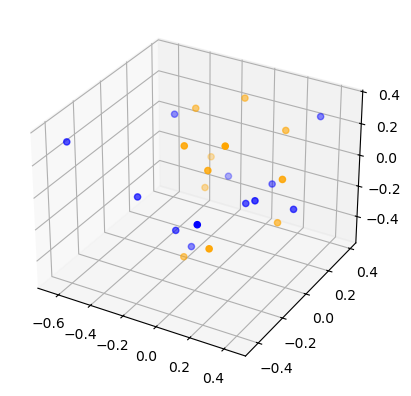

In [68]:
# now lets plot what we see with the last 12 shortlisters

t_reduced_winners = reduced_winners.transpose()

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')

ax.scatter(t_reduced_winners[0], t_reduced_winners[1], t_reduced_winners[2], color='orange')

t_reduced_sample = reduced_sample.T

ax.scatter(t_reduced_sample[0], t_reduced_sample[1], t_reduced_sample[2], color='blue')

plt.show()